In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [3]:
songs   = pd.read_csv('dataset/songs.csv')
artists = pd.read_csv('dataset/artists.csv')

print(f'songs.csv   → {songs.shape[0]:,} rows × {songs.shape[1]} columns')
print(f'artists.csv → {artists.shape[0]:,} rows × {artists.shape[1]} columns')

songs.csv   → 491,632 rows × 24 columns
artists.csv → 63,857 rows × 6 columns


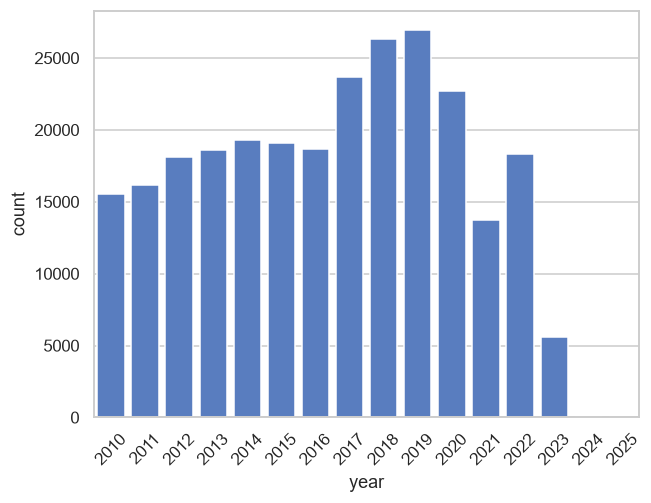

year
2025        2
2024        1
2023     5566
2022    18298
2021    13759
2020    22700
Name: count, dtype: int64


In [17]:
# relevance
ax = sns.countplot(data=songs[songs['year'] >= 2010], x='year')
ax.tick_params(axis="x", rotation=45)
plt.show()
print(songs[songs['year'] >= 2020]['year'].value_counts().sort_index(ascending=False))

---
## 1. Structure Check

In [18]:
print('=== songs.csv — first 5 rows ===')
display(songs.head())

print('\n=== Column data types ===')
display(songs.dtypes.rename('dtype').to_frame())

=== songs.csv — first 5 rows ===


,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,tempo,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres
0,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.3150,...,79.998,114000,"Fuck the bitch, now she running with my kids\n...",2019,Hip-Hop,29,143628,45.0,"[""2jwRHcdgkRhelYEMqndDKe""]",[]
1,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,Situationist Comedy,"[""Dillinger Four""]",0.171,0.957,2,-5.749,1,0.1490,...,175.317,197400,You like to stand on the other side\nPoint and...,2002,Rock,0,36619,35.0,"[""4YAN46l70QV0PGXlMg0iHi""]","[""melodic hardcore"", ""pop punk"", ""punk"", ""skat..."
2,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,1,-7.767,1,0.2480,...,142.959,178533,"It's been a while, shit, I missed the rehab, p...",2018,Hip-Hop,43,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"
3,1xBFhv5faebv3mmwxx7DnS,!Lost!,!Lost!,"[""Ril\u00e8s""]",0.729,0.552,7,-8.562,0,0.0650,...,86.103,186197,I would like to give you all my time\nI would ...,2018,Hip-Hop,0,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"
4,1SCFa6gt3r6juLsIqpdwY3,!liaF cipE,The Bree-TeenZ,"[""One Morning Left""]",0.483,0.894,9,-4.164,1,0.0546,...,140.058,200200,They scream when I'm walking in the street\nEv...,2011,Rock,0,38169,34.0,"[""4QGKWF55nqfGYToZkoZPRF""]","[""metalcore"", ""post-hardcore""]"



=== Column data types ===


,dtype
id,str
name,str
album_name,str
artists,str
danceability,float64
energy,float64
key,int64
loudness,float64
mode,int64
speechiness,float64


In [ ]:
print('=== 2024 & 2025 tracks ===')
display(songs[songs['year'] >= 2024])

In [20]:
print('=== artists.csv — first 5 rows ===')
display(artists.head())

print('\n=== Column data types ===')
display(artists.dtypes.rename('dtype').to_frame())

=== artists.csv — first 5 rows ===


,id,name,followers,popularity,genres,main_genre
0,6YROFUbu5zRCHi2xkir5pk,Brian Hyland,67223,47,[],Pop
1,5tFRohaO5yEsuJxmMnlCO9,Barns Courtney,602647,62,[],Electronic
2,3oDbviiivRWhXwIE8hxkVV,The Beach Boys,5139194,76,['baroque pop'],Classical
3,60zvRmhQHRxokEB1taAVpN,Beth Malone,1569,29,['musicals'],Classical
4,4hxDvVq5t8ebPYPdBl1F9f,HELLYEAH,769490,52,"['groove metal', 'metal']",Rock



=== Column data types ===


,dtype
id,str
name,str
followers,int64
popularity,int64
genres,str
main_genre,str


---
## 2. Missing Values

In [22]:
missing_songs = songs.isnull().sum()
missing_songs_pct = (missing_songs / len(songs) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_songs,
                           'missing_%': missing_songs_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False)

if missing_df.empty:
    print('✅ songs.csv: No missing values found')
else:
    print('⚠️  songs.csv: Missing values detected')
    display(missing_df)

⚠️  songs.csv: Missing values detected


,missing_count,missing_%
album_name,13,0.0


In [21]:
missing_artists = artists.isnull().sum()
missing_artists_pct = (missing_artists / len(artists) * 100).round(2)
missing_art_df = pd.DataFrame({'missing_count': missing_artists,
                               'missing_%': missing_artists_pct})
missing_art_df = missing_art_df[missing_art_df['missing_count'] > 0].sort_values('missing_%', ascending=False)

if missing_art_df.empty:
    print('✅ artists.csv: No missing values found')
else:
    print('⚠️  artists.csv: Missing values detected')
    display(missing_art_df)

⚠️  artists.csv: Missing values detected


,missing_count,missing_%
name,2,0.0


---
## 3. Lyrics Coverage

In [23]:
total = len(songs)
null_lyrics   = songs['lyrics'].isnull().sum()
empty_lyrics  = (songs['lyrics'].fillna('').str.strip() == '').sum()
usable_lyrics = total - empty_lyrics

print(f'Total tracks          : {total:,}')
print(f'Null lyrics           : {null_lyrics:,} ({null_lyrics/total*100:.1f}%)')
print(f'Empty/blank lyrics    : {empty_lyrics:,} ({empty_lyrics/total*100:.1f}%)')
print(f'Usable (have lyrics)  : {usable_lyrics:,} ({usable_lyrics/total*100:.1f}%)')

if usable_lyrics / total >= 0.70:
    print('\n✅ Lyrics coverage is sufficient for NLP analysis (≥70%)')
else:
    print('\n⚠️  Lyrics coverage may be too low — consider filtering or enriching with a lyrics API')

# Sample a few lyrics to visually confirm quality
print('\n=== Sample lyrics (3 tracks) ===')
sample = songs[songs['lyrics'].notna() & (songs['lyrics'].str.strip() != '')][['name','artists','lyrics']].head(3)
for _, row in sample.iterrows():
    print(f"\n🎵 {row['name']} — {row['artists']}")
    print(str(row['lyrics'][:300]) + '...')

Total tracks          : 491,632
Null lyrics           : 0 (0.0%)
Empty/blank lyrics    : 0 (0.0%)
Usable (have lyrics)  : 491,632 (100.0%)

✅ Lyrics coverage is sufficient for NLP analysis (≥70%)

=== Sample lyrics (3 tracks) ===

🎵 !! — ["Yxngxr1"]
Fuck the bitch, now she running with my kids\nAnd you said I never listen\nYeah, yeah\nYeah, yeah, yeah\nTell me all the things 'bout your family\nStruggle with your words, said you're rambling\nAlways play a game, bet you're gambling\nBut you got me on a string and I'm dancing\nTell me your childho...

🎵 !!Noble Stabbings!! — ["Dillinger Four"]
You like to stand on the other side
Point and laugh so self-satisfied
Lines drawn so plain and clear to you
So plain and clear they distort your view
Won't be ashamed of the things I've done
Live for myself I can't march to your drum
You were lost to me long ago
Tried to get past your self righteous...

🎵 !I'll Be Back! — ["Ril\u00e8s"]
It's been a while, shit, I missed the rehab, psyche was gone
Ai

---
## 4. Popularity Score Distribution

=== Popularity score — descriptive stats ===


,count,mean,std,min,25%,50%,75%,max
popularity,491632.0,18.4,17.76,0.0,0.0,15.0,31.0,98.0



Tracks with popularity = 0 : 128,573 (26.2%)
Tracks with popularity != 0: 363,059 (73.8%)
Tracks with popularity > 50: 27,306 (5.6%)

⚠️  High zero-score proportion — recommend filtering out popularity=0 tracks before modeling


C:\Users\GrenAppl\AppData\Local\Temp\ipykernel_13092\3585539805.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(pop.dropna(), vert=False, patch_artist=True,


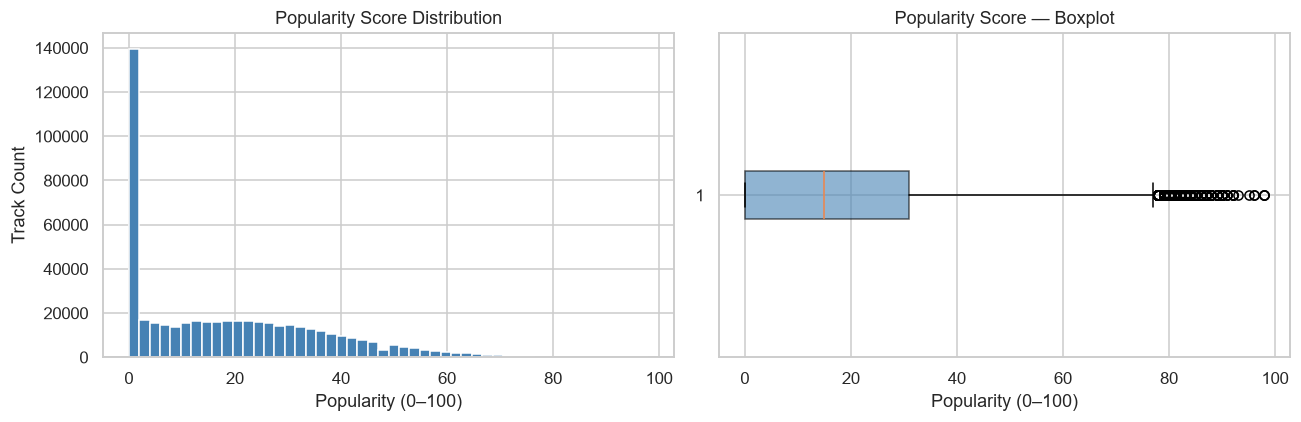

In [28]:
pop = songs['popularity']

print('=== Popularity score — descriptive stats ===')
display(pop.describe().to_frame().T.round(2))

zero_pct = (pop == 0).sum() / len(pop) * 100
above50  = (pop > 50).sum()
not_zero = (pop != 0).sum()
print(f'\nTracks with popularity = 0 : {(pop==0).sum():,} ({zero_pct:.1f}%)')
print(f'Tracks with popularity != 0: {not_zero:,} ({not_zero/len(pop)*100:.1f}%)')
print(f'Tracks with popularity > 50: {above50:,} ({above50/len(pop)*100:.1f}%)')

if zero_pct > 25:
    print('\n⚠️  High zero-score proportion — recommend filtering out popularity=0 tracks before modeling')
else:
    print('\n✅ Zero-score proportion is acceptable')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pop, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Popularity Score Distribution')
axes[0].set_xlabel('Popularity (0–100)')
axes[0].set_ylabel('Track Count')

axes[1].boxplot(pop.dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Popularity Score — Boxplot')
axes[1].set_xlabel('Popularity (0–100)')
plt.tight_layout()
plt.show()

---
## 5. Audio Feature Distributions

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,491632.000,491632.000,491632.000,491632.000,491632.000,491632.000,491632.000,491632.000,491632.000
mean,0.531,0.672,-7.821,0.085,0.241,0.103,0.221,0.468,122.829
std,0.172,0.244,3.811,0.091,0.305,0.235,0.193,0.249,29.456
min,0.046,0.000,-42.488,0.022,0.000,0.000,0.007,0.000,30.946
25%,0.412,0.499,-9.842,0.035,0.004,0.000,0.099,0.263,99.977
50%,0.533,0.716,-6.992,0.050,0.076,0.000,0.140,0.451,121.681
75%,0.654,0.884,-5.065,0.092,0.424,0.028,0.291,0.663,141.004
max,0.988,1.000,0.000,0.965,0.996,0.998,1.000,0.998,245.941


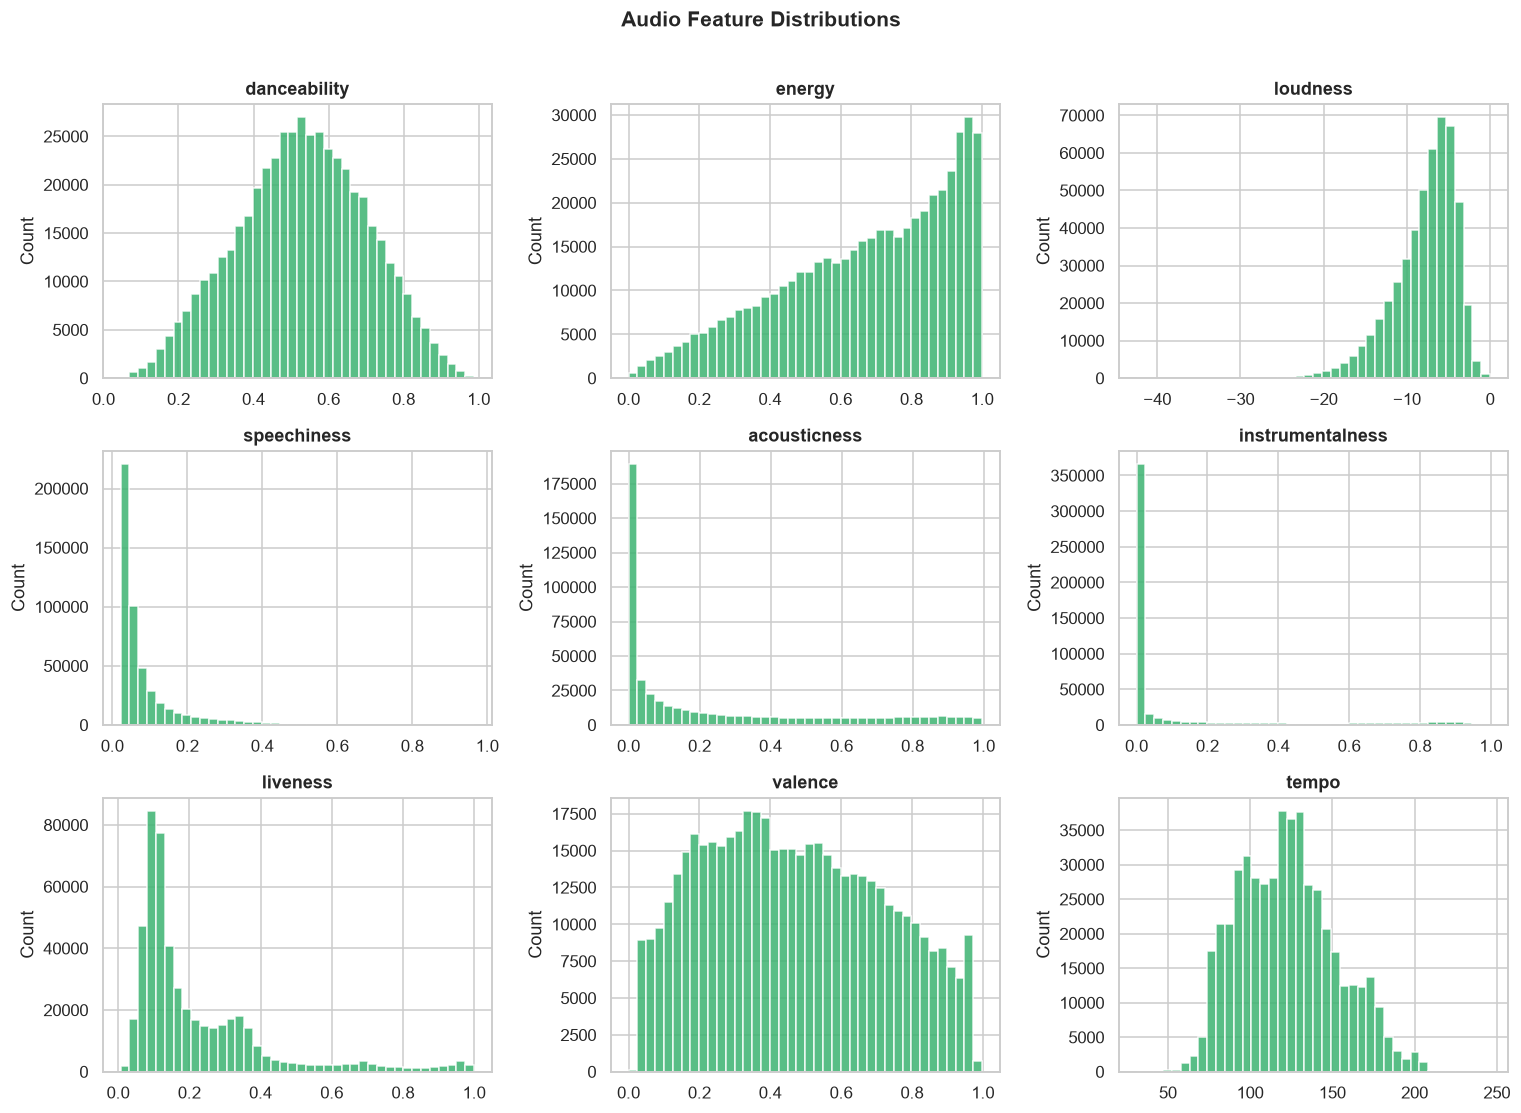

In [30]:
audio_features = ['danceability','energy','loudness','speechiness',
                  'acousticness','instrumentalness','liveness','valence','tempo']

display(songs[audio_features].describe().round(3))

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, feat in enumerate(audio_features):
    axes[i].hist(songs[feat].dropna(), bins=40, color='mediumseagreen', edgecolor='white', alpha=0.85)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Count')
plt.suptitle('Audio Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [31]:
# Expected ranges per Spotify documentation
expected_ranges = {
    'danceability'    : (0.0, 1.0),
    'energy'          : (0.0, 1.0),
    'loudness'        : (-60.0, 5.0),
    'speechiness'     : (0.0, 1.0),
    'acousticness'    : (0.0, 1.0),
    'instrumentalness': (0.0, 1.0),
    'liveness'        : (0.0, 1.0),
    'valence'         : (0.0, 1.0),
    'tempo'           : (0.0, 300.0),
    'popularity'      : (0, 100),
    'mode'            : (0, 1),
}

print('=== Out-of-range check ===')
all_ok = True
for col, (lo, hi) in expected_ranges.items():
    if col not in songs.columns:
        continue
    out = songs[(songs[col] < lo) | (songs[col] > hi)].shape[0]
    status = '✅' if out == 0 else f'⚠️  {out} out-of-range values'
    print(f'  {col:<22} [{lo}, {hi}]  →  {status}')
    if out > 0:
        all_ok = False

print('\n✅ All features within expected ranges' if all_ok else '\n⚠️  Some features have out-of-range values — inspect before modeling')

=== Out-of-range check ===
  danceability           [0.0, 1.0]  →  ✅
  energy                 [0.0, 1.0]  →  ✅
  loudness               [-60.0, 5.0]  →  ✅
  speechiness            [0.0, 1.0]  →  ✅
  acousticness           [0.0, 1.0]  →  ✅
  instrumentalness       [0.0, 1.0]  →  ✅
  liveness               [0.0, 1.0]  →  ✅
  valence                [0.0, 1.0]  →  ✅
  tempo                  [0.0, 300.0]  →  ✅
  popularity             [0, 100]  →  ✅
  mode                   [0, 1]  →  ✅

✅ All features within expected ranges


---
## 6. Temporal Coverage (Year)

=== Year column — stats ===


,count,mean,std,min,25%,50%,75%,max
year,491632,2007,13,1900,2002,2011,2017,2025


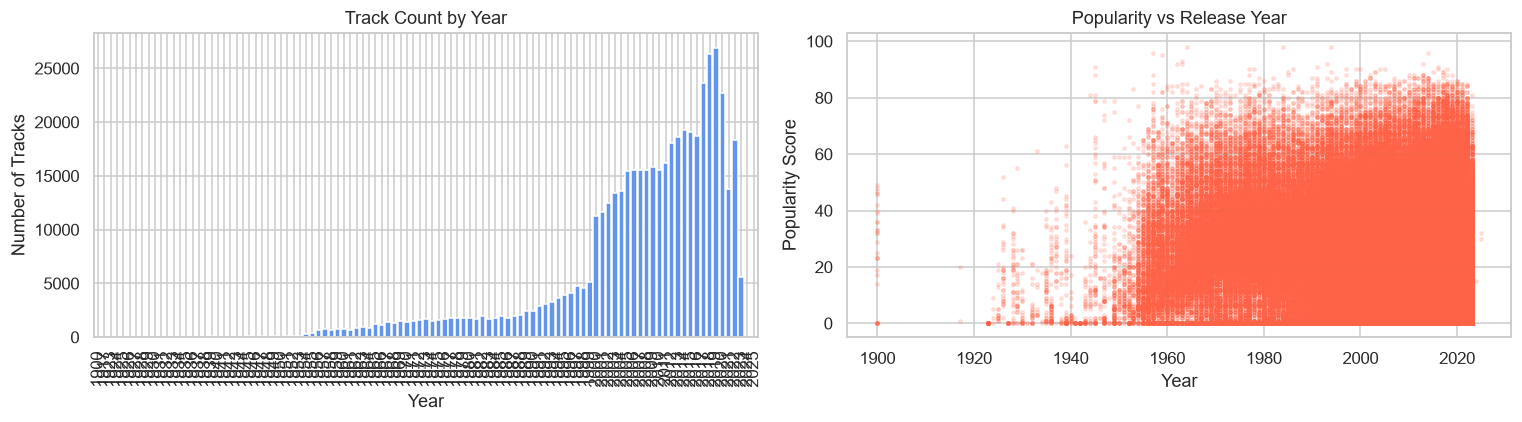


Tracks from 2018 onward: 113,593 (23.1%) — avg popularity: 19.8
Tracks before 2010     : 228,964 (46.6%) — avg popularity: 18.5

⚠️  If avg popularity differs significantly between eras, apply a year filter or control for year in your model.


In [32]:
print('=== Year column — stats ===')
display(songs['year'].describe().to_frame().T.astype(int))

year_counts = songs['year'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
year_counts.plot(kind='bar', ax=axes[0], color='cornflowerblue', edgecolor='white', width=0.85)
axes[0].set_title('Track Count by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Tracks')
axes[0].tick_params(axis='x', rotation=90)

# Popularity vs year scatter
axes[1].scatter(songs['year'], songs['popularity'], alpha=0.15, s=5, color='tomato')
axes[1].set_title('Popularity vs Release Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Popularity Score')
plt.tight_layout()
plt.show()

# Flag recency bias
recent = songs[songs['year'] >= 2018]
print(f'\nTracks from 2018 onward: {len(recent):,} ({len(recent)/len(songs)*100:.1f}%) '
      f'— avg popularity: {recent["popularity"].mean():.1f}')
older = songs[songs['year'] < 2010]
print(f'Tracks before 2010     : {len(older):,} ({len(older)/len(songs)*100:.1f}%) '
      f'— avg popularity: {older["popularity"].mean():.1f}')
print('\n⚠️  If avg popularity differs significantly between eras, apply a year filter or control for year in your model.')

---
## 7. Genre Distribution

=== Genre counts ===


,count
genre,
Rock,174353
Pop,65853
Electronic,62207
Folk,44720
Country,41860
Hip-Hop,38529
R&B,25507
Jazz,14890
Blues,14204


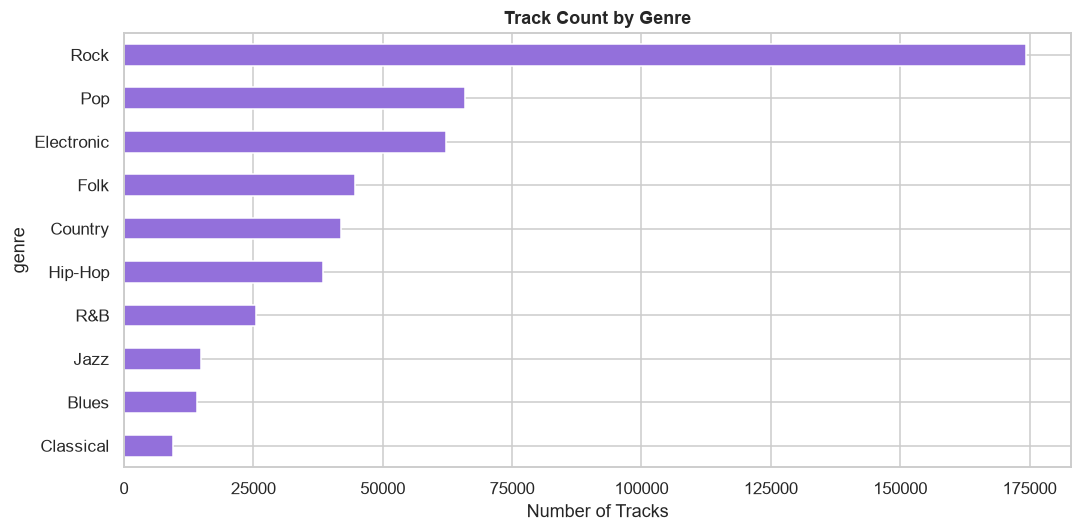


Smallest genre: Classical (9,509 tracks)
Largest genre : Rock (174,353 tracks)
Imbalance ratio: 18.3x
⚠️  High genre imbalance — consider stratified train/test split


In [33]:
genre_counts = songs['genre'].value_counts()
print('=== Genre counts ===')
display(genre_counts.to_frame())

fig, ax = plt.subplots(figsize=(10, 5))
genre_counts.plot(kind='barh', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Track Count by Genre', fontweight='bold')
ax.set_xlabel('Number of Tracks')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Genre imbalance warning
min_genre = genre_counts.min()
max_genre = genre_counts.max()
ratio = max_genre / min_genre
print(f'\nSmallest genre: {genre_counts.idxmin()} ({min_genre:,} tracks)')
print(f'Largest genre : {genre_counts.idxmax()} ({max_genre:,} tracks)')
print(f'Imbalance ratio: {ratio:.1f}x')
if ratio > 5:
    print('⚠️  High genre imbalance — consider stratified train/test split')
else:
    print('✅ Genre distribution is reasonably balanced')

---
## 8. Correlation — Audio Features vs Popularity

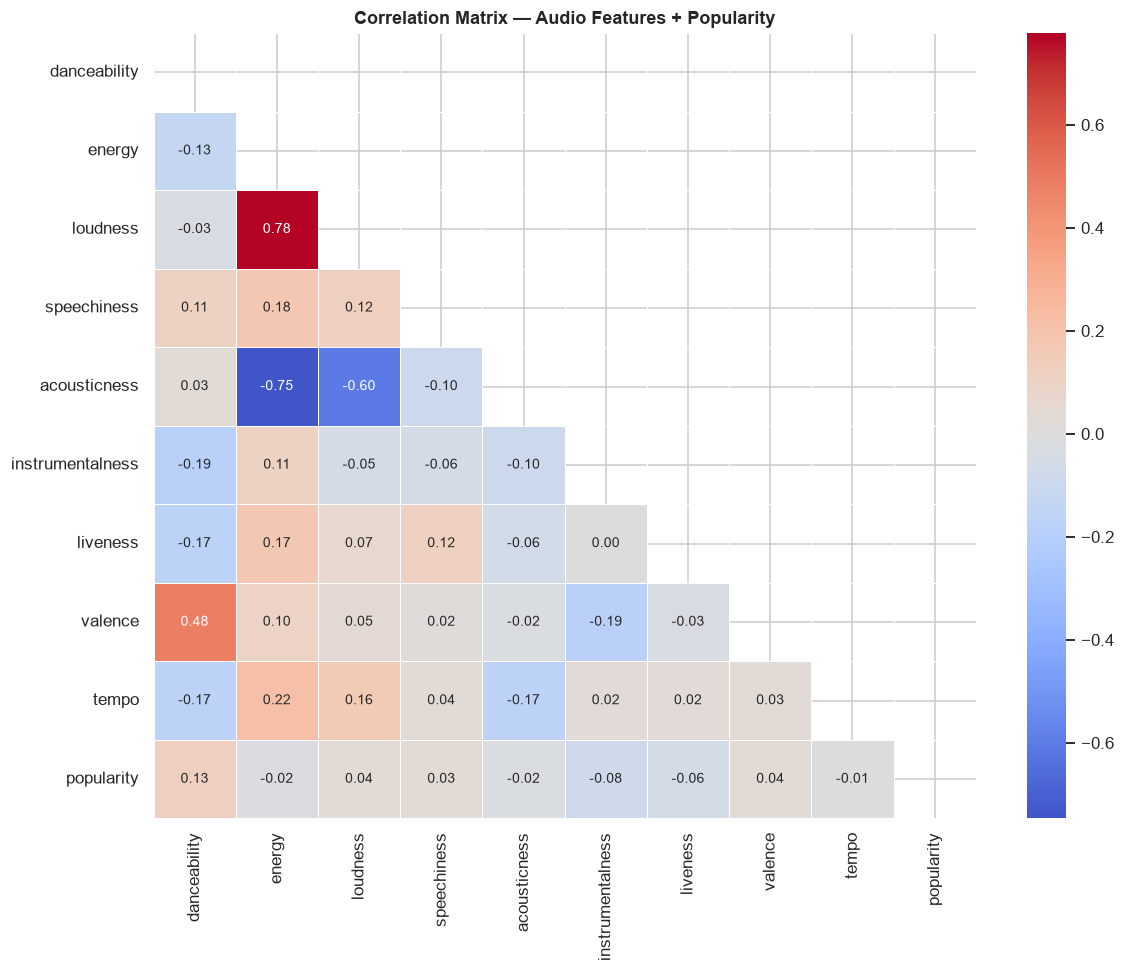

=== Correlations with popularity (sorted) ===


,corr_with_popularity
danceability,0.127
instrumentalness,-0.084
liveness,-0.058
loudness,0.037
valence,0.037
speechiness,0.032
acousticness,-0.022
energy,-0.019
tempo,-0.009


In [36]:
model_cols = audio_features + ['popularity']
corr = songs[model_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Audio Features + Popularity', fontweight='bold')
plt.tight_layout()
plt.show()

# Correlations with popularity specifically
print('=== Correlations with popularity (sorted) ===')
pop_corr = corr['popularity'].drop('popularity').sort_values(key=abs, ascending=False)
display(pop_corr.rename('corr_with_popularity').to_frame().round(3))

---
## 9. Duplicate & ID Check

In [44]:
dup_ids   = songs['id'].duplicated().sum()
dup_names = songs.duplicated(subset=['name','artists']).sum()
dup_art   = artists['id'].duplicated().sum()

print('=== Duplicate check ===')
print(f'songs.csv   — duplicate track IDs       : {dup_ids}')
print(f'songs.csv   — duplicate (name+artist)   : {dup_names}')
print(f'artists.csv — duplicate artist IDs      : {dup_art}')

for label, val in [('track IDs', dup_ids), ('name+artist combos', dup_names), ('artist IDs', dup_art)]:
    if val > 0:
        print(f'⚠️  {val} duplicate {label} — deduplicate before modeling')
    else:
        print(f'✅ No duplicate {label}')

=== Duplicate check ===
songs.csv   — duplicate track IDs       : 0
songs.csv   — duplicate (name+artist)   : 69137
artists.csv — duplicate artist IDs      : 0
✅ No duplicate track IDs
⚠️  69137 duplicate name+artist combos — deduplicate before modeling
✅ No duplicate artist IDs


In [ ]:
songs[songs.duplicated(subset=['name','artists'], keep=False)].head(8)

---
## 10. Dataset Linkage — songs ↔ artists

In [45]:
# artist_ids in songs.csv may be stored as a stringified list e.g. "['abc','def']"
# Extract first artist ID for linkage check
import ast

def extract_first_id(val):
    try:
        parsed = ast.literal_eval(str(val))
        return parsed[0] if isinstance(parsed, list) and parsed else str(val)
    except:
        return str(val).strip()

songs['primary_artist_id'] = songs['artist_ids'].apply(extract_first_id)

artist_id_set = set(artists['id'].astype(str))
matched = songs['primary_artist_id'].isin(artist_id_set).sum()
unmatched = len(songs) - matched

print('=== songs ↔ artists linkage ===')
print(f'Tracks with matching artist in artists.csv : {matched:,} ({matched/len(songs)*100:.1f}%)')
print(f'Tracks with NO match                       : {unmatched:,} ({unmatched/len(songs)*100:.1f}%)')

if matched / len(songs) >= 0.90:
    print('\n✅ Artist linkage is strong (≥90%) — safe to join for follower/popularity features')
else:
    print('\n⚠️  Low artist linkage — joining may lose significant data; investigate mismatches')

=== songs ↔ artists linkage ===
Tracks with matching artist in artists.csv : 491,632 (100.0%)
Tracks with NO match                       : 0 (0.0%)

✅ Artist linkage is strong (≥90%) — safe to join for follower/popularity features


---
## 11. Thesis Feasibility Check

In [70]:
print('=' * 55)
print('   THESIS FEASIBILITY REPORT')
print('=' * 55)

checks = {}

# 1. Enough data
checks['Sufficient dataset size (>10k tracks)'] = len(songs) > 10_000

# 2. Lyrics usable
lyrics_usable = (songs['lyrics'].notna() & (songs['lyrics'].str.strip() != '')).sum()
checks['Lyrics available for NLP (>50% coverage)'] = lyrics_usable / len(songs) > 0.50

# 3. Valence present and valid
valence_ok = songs['valence'].between(0, 1).all() and songs['valence'].notna().all()
checks['Valence column valid (0–1 range, no nulls)'] = valence_ok

# 4. Popularity not all zeros
checks['Popularity has meaningful variance (std > 10)'] = songs['popularity'].std() > 10

# 5. Genre column present
checks['Genre column populated (>90%)'] = songs['genre'].notna().mean() > 0.90

# 6. Year column useful
checks['Year column spans >10 years'] = (songs['year'].max() - songs['year'].min()) > 10

# 7. Audio features complete
audio_complete = songs[audio_features].notna().all().all()
checks['All audio features complete (no nulls)'] = audio_complete

# 8. Artist linkage
checks['Artist linkage ≥90% (songs ↔ artists)'] = matched / len(songs) >= 0.90

# Print results
all_pass = True
for check, passed in checks.items():
    icon = '✅' if passed else '❌'
    print(f'  {icon}  {check}')
    if not passed:
        all_pass = False

print('=' * 55)
if all_pass:
    print('  🎉 VERDICT: Dataset is VALID for your thesis')
else:
    failed = sum(1 for v in checks.values() if not v)
    print(f'  ⚠️  VERDICT: {failed} check(s) failed — review items above')
print('=' * 55 + '\n')

filtered = songs[
    (songs['popularity'] > 0) &
    (songs['lyrics'].notna()) &
    (songs['lyrics'].str.strip() != '') &
    (songs['year'] <= 2023)
]
print(f'{len(filtered):,} total tracks')

   THESIS FEASIBILITY REPORT
  ✅  Sufficient dataset size (>10k tracks)
  ✅  Lyrics available for NLP (>50% coverage)
  ✅  Valence column valid (0–1 range, no nulls)
  ✅  Popularity has meaningful variance (std > 10)
  ✅  Genre column populated (>90%)
  ✅  Year column spans >10 years
  ✅  All audio features complete (no nulls)
  ✅  Artist linkage ≥90% (songs ↔ artists)
  🎉 VERDICT: Dataset is VALID for your thesis

363,056 total tracks


---
## 12. Valence Distribution — Key NLP Alignment Feature

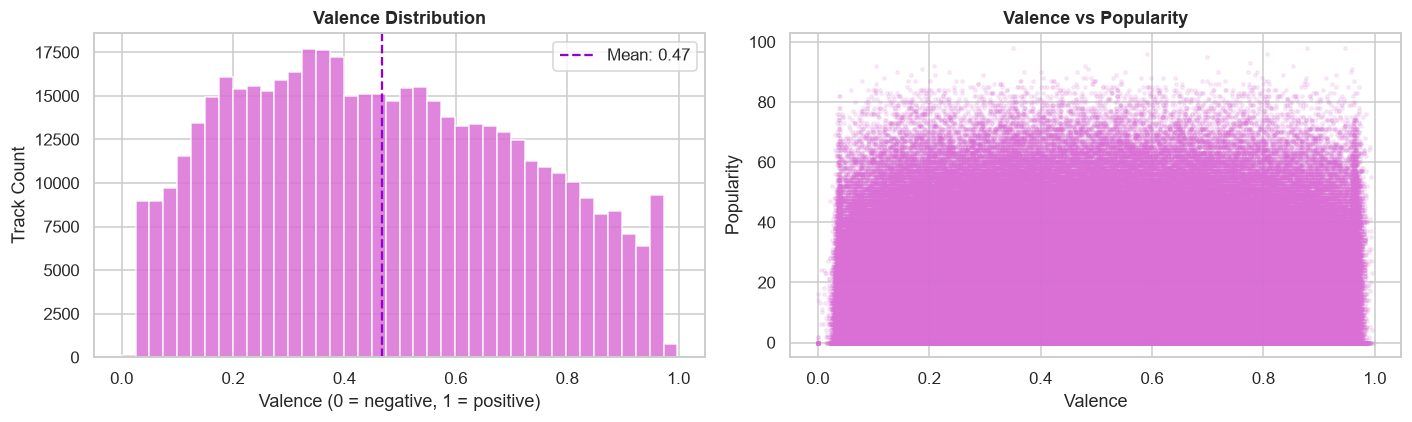

Valence mean : 0.468
Valence std  : 0.249
Corr(valence, popularity): 0.037

→ Valence will be normalized to −1 to +1 before computing alignment gap.


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Valence distribution
axes[0].hist(songs['valence'], bins=40, color='orchid', edgecolor='white', alpha=0.85)
axes[0].axvline(songs['valence'].mean(), color='darkviolet', linestyle='--', label=f'Mean: {songs["valence"].mean():.2f}')
axes[0].set_title('Valence Distribution', fontweight='bold')
axes[0].set_xlabel('Valence (0 = negative, 1 = positive)')
axes[0].set_ylabel('Track Count')
axes[0].legend()

# Valence vs popularity
axes[1].scatter(songs['valence'], songs['popularity'], alpha=0.12, s=5, color='orchid')
axes[1].set_title('Valence vs Popularity', fontweight='bold')
axes[1].set_xlabel('Valence')
axes[1].set_ylabel('Popularity')
plt.tight_layout()
plt.show()

print(f'Valence mean : {songs["valence"].mean():.3f}')
print(f'Valence std  : {songs["valence"].std():.3f}')
print(f'Corr(valence, popularity): {songs[["valence","popularity"]].corr().iloc[0,1]:.3f}')
print('\n→ Valence will be normalized to −1 to +1 before computing alignment gap.')